# Импорты и общие настройки

In [1]:
import os
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import transforms
from pathlib import Path
import json
from dataclasses import dataclass
import math
import sklearn
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler


plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


# Датасет

In [2]:
def make_synthetic_demand(n_days: int = 1200, start: str = "2021-01-01") -> pd.DataFrame:
    # Строим ежедневную временную шкалу и индекс времени t.
    dates = pd.date_range(start=start, periods=n_days, freq="D")
    t = np.arange(n_days)

    # Собираем ряд из нескольких компонент: тренд, сезонность, шум и редкие всплески.
    trend = 80 + 0.035 * t
    weekly = 8 * np.sin(2 * np.pi * t / 7) + 3 * np.cos(2 * np.pi * t / 7)
    yearly = 10 * np.sin(2 * np.pi * t / 365.25)
    noise = np.random.normal(loc=0.0, scale=3.2, size=n_days)

    day_of_week = pd.Series(dates).dt.dayofweek.to_numpy()
    weekend_bonus = np.where(day_of_week >= 5, 6.5, 0.0)

    promo = (np.random.rand(n_days) < 0.04).astype(float)
    promo_effect = promo * np.random.uniform(8, 18, size=n_days)

    # В конце ряда добавляем небольшой сдвиг режима, чтобы задача была ближе к жизни.
    regime_shift = np.where(t >= int(n_days * 0.82), 20.0, 0.0)

    sales = trend + weekly + yearly + weekend_bonus + promo_effect + regime_shift + noise
    sales = np.maximum(sales, 5.0)

    df = pd.DataFrame({
        "date": dates,
        "sales": sales,
        "promo": promo.astype(int),
    })
    return df

# Генерируем один демонстрационный ряд, на котором дальше строим все эксперименты.
df = make_synthetic_demand()
df.head()

,date,sales,promo
0,2021-01-01,84.589485,0
1,2021-01-02,94.389691,0
2,2021-01-03,96.118444,0
3,2021-01-04,86.262703,0
4,2021-01-05,73.904287,0


train: 2021-01-01 → 2023-04-20 | 840 строк
val:   2023-04-21 → 2023-10-17 | 180 строк
test:  2023-10-18 → 2024-04-14 | 180 строк


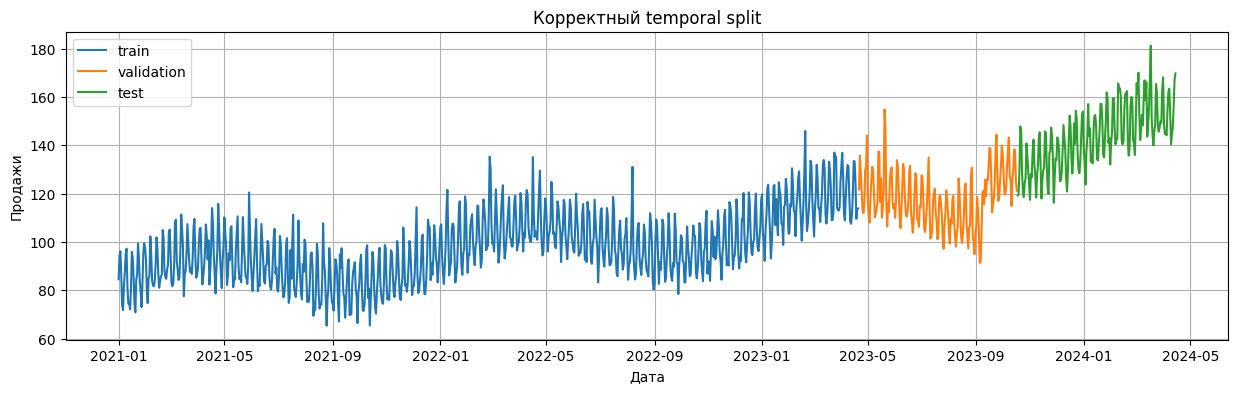

In [3]:
@dataclass
class SplitConfig:
    train_frac: float = 0.70
    val_frac: float = 0.15
    test_frac: float = 0.15

def temporal_split(df: pd.DataFrame, cfg: SplitConfig = SplitConfig()):
    # Проверяем, что доли действительно покрывают весь датасет.
    assert math.isclose(cfg.train_frac + cfg.val_frac + cfg.test_frac, 1.0, rel_tol=1e-9)
    n = len(df)
    train_end = int(n * cfg.train_frac)
    val_end = int(n * (cfg.train_frac + cfg.val_frac))

    # Ключевая идея: train, validation и test идут по времени друг за другом.
    train_df = df.iloc[:train_end].copy()
    val_df = df.iloc[train_end:val_end].copy()
    test_df = df.iloc[val_end:].copy()
    return train_df, val_df, test_df

train_df, val_df, test_df = temporal_split(df)

print(f"train: {train_df['date'].min().date()} → {train_df['date'].max().date()} | {len(train_df)} строк")
print(f"val:   {val_df['date'].min().date()} → {val_df['date'].max().date()} | {len(val_df)} строк")
print(f"test:  {test_df['date'].min().date()} → {test_df['date'].max().date()} | {len(test_df)} строк")

fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(train_df["date"], train_df["sales"], label="train")
ax.plot(val_df["date"], val_df["sales"], label="validation")
ax.plot(test_df["date"], test_df["sales"], label="test")
ax.set_title("Корректный temporal split")
ax.set_xlabel("Дата")
ax.set_ylabel("Продажи")
ax.legend()
plt.show()

In [4]:
def add_calendar_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    # Календарные признаки часто дают модели простую и полезную сезонную структуру.
    out["dayofweek"] = out["date"].dt.dayofweek
    out["month"] = out["date"].dt.month

    # Синус/косинус кодируют цикличность без искусственного разрыва между концом и началом периода.
    out["dow_sin"] = np.sin(2 * np.pi * out["dayofweek"] / 7)
    out["dow_cos"] = np.cos(2 * np.pi * out["dayofweek"] / 7)

    out["month_sin"] = np.sin(2 * np.pi * out["month"] / 12)
    out["month_cos"] = np.cos(2 * np.pi * out["month"] / 12)
    return out

def add_lag_features(df: pd.DataFrame, target_col: str = "sales") -> pd.DataFrame:
    out = df.copy()

    # Лаги смотрят только назад во времени и поэтому безопасны с точки зрения leakage.
    for lag in [1, 2, 3, 7, 14, 28]:
        out[f"lag_{lag}"] = out[target_col].shift(lag)

    # Перед rolling используем shift(1), чтобы статистика не включала текущее наблюдение.
    out["rolling_mean_7"] = out[target_col].shift(1).rolling(window=7).mean()
    out["rolling_std_7"] = out[target_col].shift(1).rolling(window=7).std()
    out["rolling_mean_28"] = out[target_col].shift(1).rolling(window=28).mean()
    out["rolling_std_28"] = out[target_col].shift(1).rolling(window=28).std()
    return out

features_df = add_calendar_features(df)
features_df = add_lag_features(features_df)

# Первые строки неизбежно теряются из-за лагов и rolling-окон.
features_df = features_df.dropna().reset_index(drop=True)
features_df.head()

,date,sales,promo,dayofweek,month,dow_sin,dow_cos,month_sin,month_cos,lag_1,lag_2,lag_3,lag_7,lag_14,lag_28,rolling_mean_7,rolling_std_7,rolling_mean_28,rolling_std_28
0,2021-01-29,95.129535,1,4,1,-0.433884,-0.900969,0.500000,0.866025,82.242501,73.084828,79.225235,86.546963,80.355389,84.589485,85.430829,8.814591,84.065902,8.872967
1,2021-01-30,99.491039,0,5,1,-0.974928,-0.222521,0.500000,0.866025,95.129535,82.242501,73.084828,99.306048,95.902625,94.389691,86.656911,9.561017,84.442332,9.116245
2,2021-01-31,97.691081,0,6,1,-0.781831,0.623490,0.500000,0.866025,99.491039,95.129535,82.242501,93.731800,93.668568,96.118444,86.683338,9.601975,84.624523,9.369857
3,2021-02-01,92.864018,0,0,2,0.000000,1.000000,0.866025,0.500000,97.691081,99.491039,95.129535,83.878428,85.251661,86.262703,87.248950,10.185265,84.680689,9.445713
4,2021-02-02,80.133775,0,1,2,0.781831,0.623490,0.866025,0.500000,92.864018,97.691081,99.491039,79.225235,74.597539,73.904287,88.532605,10.255665,84.916450,9.568250


In [5]:
# Собираем финальный набор признаков для baseline-моделей.
feature_cols = [
    "promo",
    "dayofweek", "month",
    "dow_sin", "dow_cos",
    "month_sin", "month_cos",
    "lag_1", "lag_2", "lag_3", "lag_7", "lag_14", "lag_28",
    "rolling_mean_7", "rolling_std_7", "rolling_mean_28", "rolling_std_28",
]

target_col = "sales"

# Разбиение выполняем после построения признаков, но без перемешивания по времени.
train_feat, val_feat, test_feat = temporal_split(features_df)

X_train = train_feat[feature_cols]
y_train = train_feat[target_col]

X_val = val_feat[feature_cols]
y_val = val_feat[target_col]

X_test = test_feat[feature_cols]
y_test = test_feat[target_col]

print("Размерности:")
print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_val:  ", X_val.shape, "| y_val:  ", y_val.shape)
print("X_test: ", X_test.shape, "| y_test: ", y_test.shape)

Размерности:
X_train: (820, 17) | y_train: (820,)
X_val:   (176, 17) | y_val:   (176,)
X_test:  (176, 17) | y_test:  (176,)


# Leakage

In [6]:
def rmse(y_true, y_pred) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def mape(y_true, y_pred, eps: float = 1e-8) -> float:
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.maximum(np.abs(y_true), eps)
    return float(np.mean(np.abs((y_true - y_pred) / denom)) * 100)

def evaluate_regression(y_true, y_pred, model_name: str) -> pd.DataFrame:
    return pd.DataFrame([{
        "model": model_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "MAPE_%": mape(y_true, y_pred),
    }])
val_pred_naive = val_feat["lag_1"].to_numpy()
test_pred_naive = test_feat["lag_1"].to_numpy()

# Moving average baseline: вместо одного прошлого значения берём короткое среднее окно.
val_pred_ma7 = val_feat["rolling_mean_7"].to_numpy()
test_pred_ma7 = test_feat["rolling_mean_7"].to_numpy()

baseline_results_val = pd.concat([
    evaluate_regression(y_val, val_pred_naive, "Naive (lag_1)"),
    evaluate_regression(y_val, val_pred_ma7, "MovingAverage(7)"),
], ignore_index=True)

baseline_results_test = pd.concat([
    evaluate_regression(y_test, test_pred_naive, "Naive (lag_1)"),
    evaluate_regression(y_test, test_pred_ma7, "MovingAverage(7)"),
], ignore_index=True)

In [7]:
# Ridge чувствителен к масштабу признаков, поэтому его обучаем на стандартизованных данных.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

# Деревья к масштабу почти нечувствительны, поэтому RandomForest оставляем на исходных признаках.
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train, y_train)

val_pred_ridge = ridge.predict(X_val_scaled)
test_pred_ridge = ridge.predict(X_test_scaled)

val_pred_rf = rf.predict(X_val)
test_pred_rf = rf.predict(X_test)

In [8]:
# --- Антипример 1: random split ---
# Даже без явного leakage перемешивание дат делает задачу искусственно проще.
random_X_train, random_X_test, random_y_train, random_y_test = train_test_split(
    features_df[feature_cols],
    features_df[target_col],
    test_size=0.2,
    random_state=42,
    shuffle=True,
)
scaler_random = StandardScaler()
ridge_random = Ridge(alpha=1.0)
ridge_random.fit(scaler_random.fit_transform(random_X_train), random_y_train)
random_pred = ridge_random.predict(scaler_random.transform(random_X_test))

random_split_result = evaluate_regression(random_y_test, random_pred, "Ridge + random split")

# --- Антипример 2: centered rolling использует будущее ---
# При center=True окно захватывает наблюдения и слева, и справа от текущей точки.
leaky_df = add_calendar_features(df)
leaky_df = add_lag_features(leaky_df)
leaky_df["rolling_mean_center_7_BAD"] = leaky_df["sales"].rolling(window=7, center=True).mean()

# --- Антипример 3: экстремальный leakage, когда признак почти совпадает с target ---
# Такой пример нарочито искусственный, но он хорошо показывает,
# как подозрительно низкие метрики могут быть следствием утечки, а не сильной модели.
leaky_df["target_proxy_BAD"] = leaky_df["sales"] + np.random.normal(loc=0.0, scale=0.3, size=len(leaky_df))
leaky_df = leaky_df.dropna().reset_index(drop=True)

# Сравним умеренный leakage и сильный leakage на одном и том же leaky test.
leaky_train, leaky_val, leaky_test = temporal_split(leaky_df)

soft_leak_cols = feature_cols + ["rolling_mean_center_7_BAD"]
strong_leak_cols = feature_cols + ["target_proxy_BAD"]

scaler_soft_leak = StandardScaler()
ridge_soft_leak = Ridge(alpha=1.0)
ridge_soft_leak.fit(
    scaler_soft_leak.fit_transform(leaky_train[soft_leak_cols]),
    leaky_train[target_col],
)
soft_leak_pred = ridge_soft_leak.predict(scaler_soft_leak.transform(leaky_test[soft_leak_cols]))

scaler_strong_leak = StandardScaler()
ridge_strong_leak = Ridge(alpha=1.0)
ridge_strong_leak.fit(
    scaler_strong_leak.fit_transform(leaky_train[strong_leak_cols]),
    leaky_train[target_col],
)
strong_leak_pred = ridge_strong_leak.predict(scaler_strong_leak.transform(leaky_test[strong_leak_cols]))

val_results = pd.concat([
    baseline_results_val,
    evaluate_regression(y_val, val_pred_ridge, "Ridge"),
    evaluate_regression(y_val, val_pred_rf, "RandomForest"),
], ignore_index=True).sort_values("MAE").reset_index(drop=True)

test_results = pd.concat([
    baseline_results_test,
    evaluate_regression(y_test, test_pred_ridge, "Ridge"),
    evaluate_regression(y_test, test_pred_rf, "RandomForest"),
], ignore_index=True).sort_values("MAE").reset_index(drop=True)

print("No leakage:")
display(test_results)

leakage_results = pd.concat([
    evaluate_regression(y_test, test_pred_ridge, "Ridge + temporal split"),
    random_split_result,
    evaluate_regression(leaky_test[target_col], soft_leak_pred, "Ridge + centered rolling leakage"),
    evaluate_regression(leaky_test[target_col], strong_leak_pred, "Ridge + target proxy leakage"),
], ignore_index=True).sort_values("MAE").reset_index(drop=True)
print("Leakage:")
display(leakage_results)

No leakage:


,model,MAE,RMSE,MAPE_%
0,Ridge,2.884621,3.685829,2.017301
1,Naive (lag_1),7.742091,9.529517,5.418472
2,MovingAverage(7),8.235508,9.586691,5.704636
3,RandomForest,14.484271,18.012424,9.541849


Leakage:


,model,MAE,RMSE,MAPE_%
0,Ridge + target proxy leakage,0.261662,0.335133,0.183242
1,Ridge + centered rolling leakage,2.521021,3.213356,1.776941
2,Ridge + random split,2.817204,3.475067,2.728954
3,Ridge + temporal split,2.884621,3.685829,2.017301


### Несмотря на такие замечательные метрики при Leakage - их нельзя взять за истинные.